In [2]:
from google.colab import files
uploaded = files.upload()

Saving weather.csv to weather.csv


In [34]:
import pandas as pd

df = pd.read_csv("weather.csv")
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,8.0,24.3,0.0,3.4,6.3,NW,30.0,SW,NW,6.0,...,29,1019.7,1015.0,7,7,14.4,23.6,No,3.6,Yes
1,14.0,26.9,3.6,4.4,9.7,ENE,39.0,E,W,4.0,...,36,1012.4,1008.4,5,3,17.5,25.7,Yes,3.6,Yes
2,13.7,23.4,3.6,5.8,3.3,NW,85.0,N,NNE,6.0,...,69,1009.5,1007.2,8,7,15.4,20.2,Yes,39.8,Yes
3,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,W,30.0,...,56,1005.5,1007.0,2,7,13.5,14.1,Yes,2.8,Yes
4,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,ESE,20.0,...,49,1018.3,1018.5,7,7,11.1,15.4,Yes,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,9.0,30.7,0.0,7.6,12.1,NNW,76.0,SSE,NW,7.0,...,15,1016.1,1010.8,1,3,20.4,30.0,No,0.0,No
362,7.1,28.4,0.0,11.6,12.7,N,48.0,NNW,NNW,2.0,...,22,1020.0,1016.9,0,1,17.2,28.2,No,0.0,No
363,12.5,19.9,0.0,8.4,5.3,ESE,43.0,ENE,ENE,11.0,...,47,1024.0,1022.8,3,2,14.5,18.3,No,0.0,No
364,12.5,26.9,0.0,5.0,7.1,NW,46.0,SSW,WNW,6.0,...,39,1021.0,1016.2,6,7,15.8,25.9,No,0.0,No


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Check missing values in each column
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          3
WindGustDir       3
WindGustSpeed     2
WindDir9am       31
WindDir3pm        1
WindSpeed9am      7
WindSpeed3pm      0
Humidity9am       0
Humidity3pm       0
Pressure9am       0
Pressure3pm       0
Cloud9am          0
Cloud3pm          0
Temp9am           0
Temp3pm           0
RainToday         0
RISK_MM           0
RainTomorrow      0
dtype: int64


In [6]:
# Total missing values in dataset
total_missing = df.isnull().sum().sum()
print("\nTotal Missing Values:", total_missing)


Total Missing Values: 47


In [7]:
# Drop rows with any missing values
df_cleaned = df.dropna()

print("\nShape before cleaning:", df.shape)
print("Shape after cleaning:", df_cleaned.shape)


Shape before cleaning: (366, 22)
Shape after cleaning: (328, 22)


In [8]:
# Fill numeric columns with mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [9]:
# Fill categorical columns with mode (most frequent value)
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Check again for missing values
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())


Missing Values After Cleaning:

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64


In [11]:

# Create new column: Average Temperature
df['AvgTemp'] = (df['MinTemp'] + df['MaxTemp']) / 2

# Display first few values
print("\nAverage Temperature Column Added:\n")
print(df[['MinTemp', 'MaxTemp', 'AvgTemp']].head())

# Calculate statistics
avg_temp = df['AvgTemp'].mean()
max_temp = df['MaxTemp'].max()
min_temp = df['MinTemp'].min()

print("\nTemperature Statistics:")
print("Average Temperature:", avg_temp)
print("Maximum Temperature:", max_temp)
print("Minimum Temperature:", min_temp)

# Identify extreme days
hottest_day = df.loc[df['MaxTemp'].idxmax()]
coldest_day = df.loc[df['MinTemp'].idxmin()]

print("\nHottest Day Details:\n", hottest_day)
print("\nColdest Day Details:\n", coldest_day)


Average Temperature Column Added:

   MinTemp  MaxTemp  AvgTemp
0      8.0     24.3    16.15
1     14.0     26.9    20.45
2     13.7     23.4    18.55
3     13.3     15.5    14.40
4      7.6     16.1    11.85

Temperature Statistics:
Average Temperature: 13.90792349726776
Maximum Temperature: 35.8
Minimum Temperature: -5.3

Hottest Day Details:
 MinTemp            17.5
MaxTemp            35.8
Rainfall            0.0
Evaporation         9.4
Sunshine           13.3
WindGustDir         SSE
WindGustSpeed      57.0
WindDir9am          NNW
WindDir3pm           NW
WindSpeed9am        6.0
WindSpeed3pm         19
Humidity9am          56
Humidity3pm          24
Pressure9am      1011.8
Pressure3pm      1006.5
Cloud9am              0
Cloud3pm              1
Temp9am            24.7
Temp3pm            34.5
RainToday            No
RISK_MM             0.0
RainTomorrow         No
AvgTemp           26.65
Name: 71, dtype: object

Coldest Day Details:
 MinTemp            -5.3
MaxTemp            13.1
Rain

In [14]:
df['AvgHumidity'] = (df['Humidity9am'] + df['Humidity3pm']) / 2

In [15]:
print("\nAverage Humidity Column Added:\n")
print(df[['Humidity9am', 'Humidity3pm', 'AvgHumidity']].head())



Average Humidity Column Added:

   Humidity9am  Humidity3pm  AvgHumidity
0           68           29         48.5
1           80           36         58.0
2           82           69         75.5
3           62           56         59.0
4           68           49         58.5


In [16]:
avg_humidity = df['AvgHumidity'].mean()
print("\nOverall Average Humidity:", avg_humidity)


Overall Average Humidity: 58.27732240437158


In [17]:
humidity_rain = df.groupby('RainTomorrow')['AvgHumidity'].mean()

In [18]:
print("\nAverage Humidity based on Rain Tomorrow:\n")
print(humidity_rain)


Average Humidity based on Rain Tomorrow:

RainTomorrow
No     56.26000
Yes    67.44697
Name: AvgHumidity, dtype: float64


In [19]:
rain_counts = df['RainTomorrow'].value_counts()

In [20]:
print("\nRain Tomorrow Count:\n")
print(rain_counts)


Rain Tomorrow Count:

RainTomorrow
No     300
Yes     66
Name: count, dtype: int64


In [21]:
rain_percentage = df['RainTomorrow'].value_counts(normalize=True) * 100

In [22]:
print("\nRain Tomorrow Percentage (%):\n")
print(rain_percentage)


Rain Tomorrow Percentage (%):

RainTomorrow
No     81.967213
Yes    18.032787
Name: proportion, dtype: float64


In [23]:
print("\nInterpretation:")
for label, count in rain_counts.items():
    print(f"{label} Days: {count}")


Interpretation:
No Days: 300
Yes Days: 66


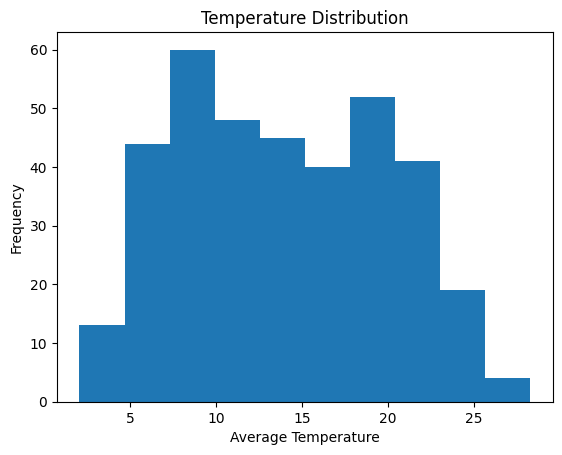

In [24]:
plt.figure()
plt.hist(df['AvgTemp'])
plt.title("Temperature Distribution")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.show()

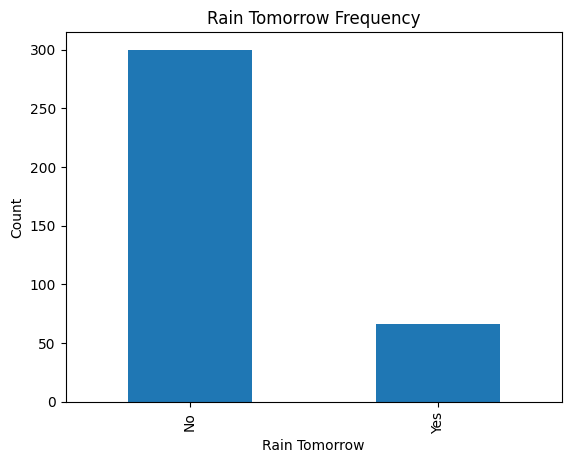

In [25]:
plt.figure()
df['RainTomorrow'].value_counts().plot(kind='bar')
plt.title("Rain Tomorrow Frequency")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Count")
plt.show()

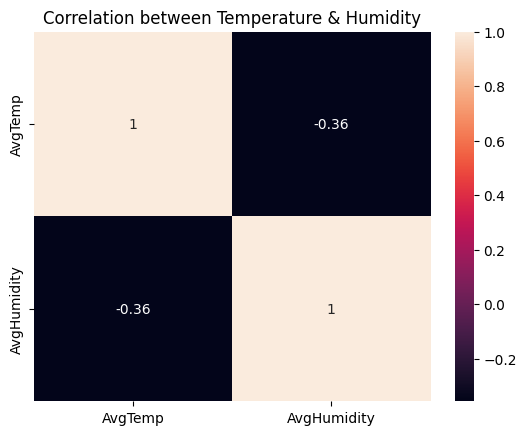

In [26]:
subset = df[['AvgTemp', 'AvgHumidity']]

plt.figure()
sns.heatmap(subset.corr(), annot=True)
plt.title("Correlation between Temperature & Humidity")
plt.show()

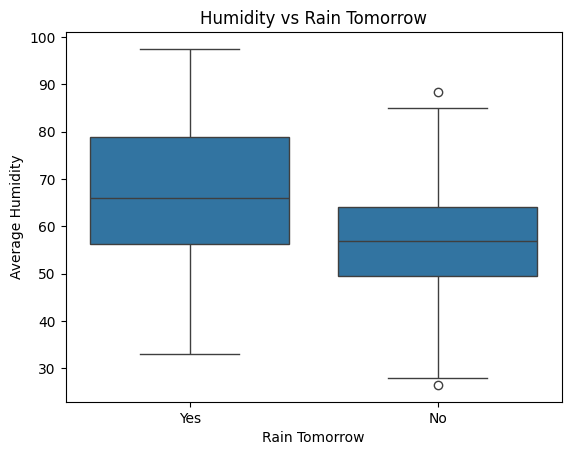

In [27]:
plt.figure()
sns.boxplot(x=df['RainTomorrow'], y=df['AvgHumidity'])
plt.title("Humidity vs Rain Tomorrow")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Average Humidity")
plt.show()

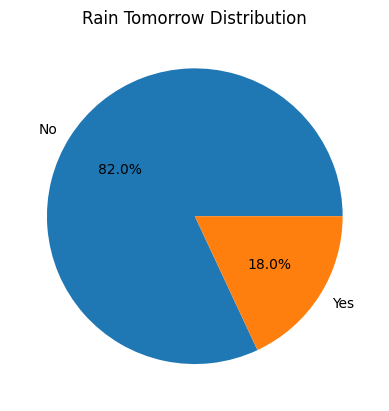

In [28]:
rain_counts = df['RainTomorrow'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(rain_counts, labels=rain_counts.index, autopct='%1.1f%%')
plt.title("Rain Tomorrow Distribution")
plt.show()

In [29]:
hottest_index = df['MaxTemp'].idxmax()
coldest_index = df['MinTemp'].idxmin()

In [30]:
hottest_day = df.loc[hottest_index]
coldest_day = df.loc[coldest_index]

In [32]:
print("Hottest Day Details:\n")
print(hottest_day)

print("\nColdest Day Details:\n")
print(coldest_day)

Hottest Day Details:

MinTemp            17.5
MaxTemp            35.8
Rainfall            0.0
Evaporation         9.4
Sunshine           13.3
WindGustDir         SSE
WindGustSpeed      57.0
WindDir9am          NNW
WindDir3pm           NW
WindSpeed9am        6.0
WindSpeed3pm         19
Humidity9am          56
Humidity3pm          24
Pressure9am      1011.8
Pressure3pm      1006.5
Cloud9am              0
Cloud3pm              1
Temp9am            24.7
Temp3pm            34.5
RainToday            No
RISK_MM             0.0
RainTomorrow         No
AvgTemp           26.65
AvgHumidity        40.0
Name: 71, dtype: object

Coldest Day Details:

MinTemp            -5.3
MaxTemp            13.1
Rainfall            0.0
Evaporation         2.2
Sunshine            7.9
WindGustDir          NW
WindGustSpeed      33.0
WindDir9am            N
WindDir3pm          NNW
WindSpeed9am        4.0
WindSpeed3pm         20
Humidity9am          94
Humidity3pm          47
Pressure9am      1029.6
Pressure3pm      10

In [33]:
print("\nAnalysis Completed Successfully ✅")


Analysis Completed Successfully ✅
